In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Step 1: Read data from .txt file
file_path = "BOD2024-Nhung/GGA/File txt/U1-VS1-26-03-2024/2.5-0/U1-2.5-0-04042024-Q=49.96mL_phút-1.txt"  # Path to your file
df = pd.read_csv(file_path, sep="\t", header=None, names=["Time", "DO"])
df.head()

,Time,DO
0,1,278.57999
1,2,278.57999
2,3,278.42999
3,4,278.32999
4,5,278.22000


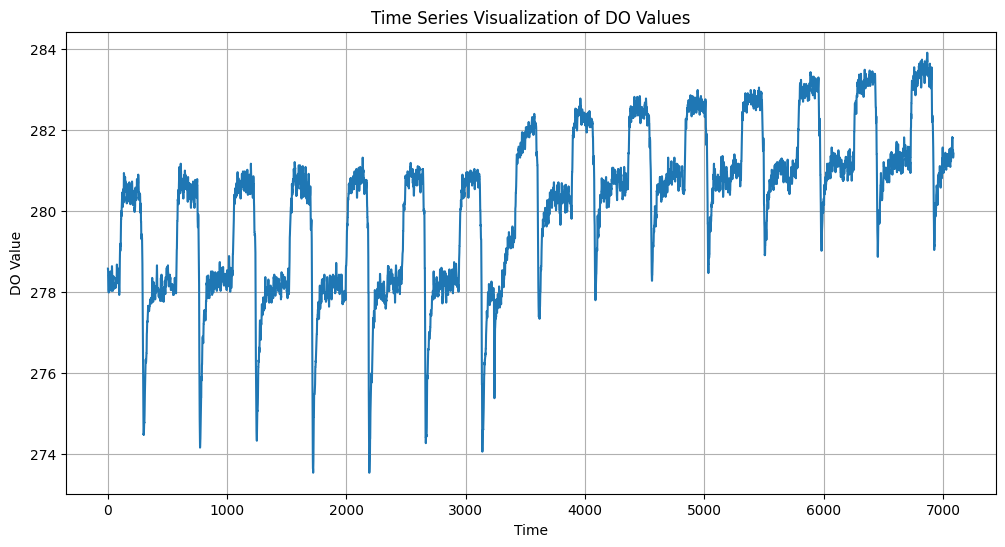

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df["Time"], df["DO"])
plt.xlabel("Time")
plt.ylabel("DO Value")
plt.title("Time Series Visualization of DO Values")
plt.grid(True)
plt.show()

In [5]:
train_len = round(len(df)*0.6)
train = df[:train_len]
test = df[train_len:]

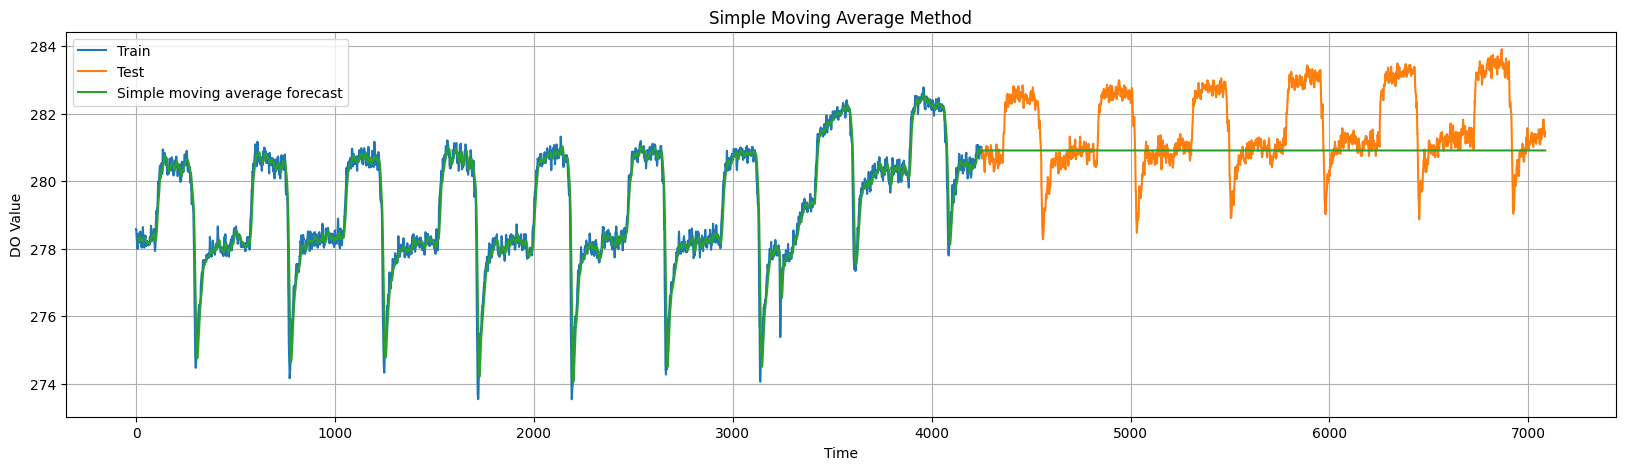

,Method,RMSE,MAPE
0,Simple moving average forecast,1.29,0.34


In [ ]:
y_hat_sma = df.copy()
ma_window = 12
y_hat_sma['sma_forecast'] = df['DO'].rolling(ma_window).mean()
y_hat_sma['sma_forecast'][train_len:] = y_hat_sma['sma_forecast'][train_len-1]
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['DO'], label='Train')
plt.plot(test['DO'], label='Test')
plt.plot(y_hat_sma['sma_forecast'], label='Simple moving average forecast')
plt.title('Simple Moving Average Method')
plt.xlabel("Time")
plt.ylabel("DO Value")
plt.legend(loc='best')
plt.show()
rmse = np.sqrt(mean_squared_error(test['DO'], y_hat_sma['sma_forecast'][train_len:])).round(2)
mape = np.round(np.mean(np.abs(test['DO']-y_hat_sma['sma_forecast'][train_len:])/test['DO'])*100,2)

results = pd.DataFrame({'Method':['Simple moving average forecast'], 'MAPE': [mape], 'RMSE': [rmse]})
results = results[['Method', 'RMSE', 'MAPE']]
results

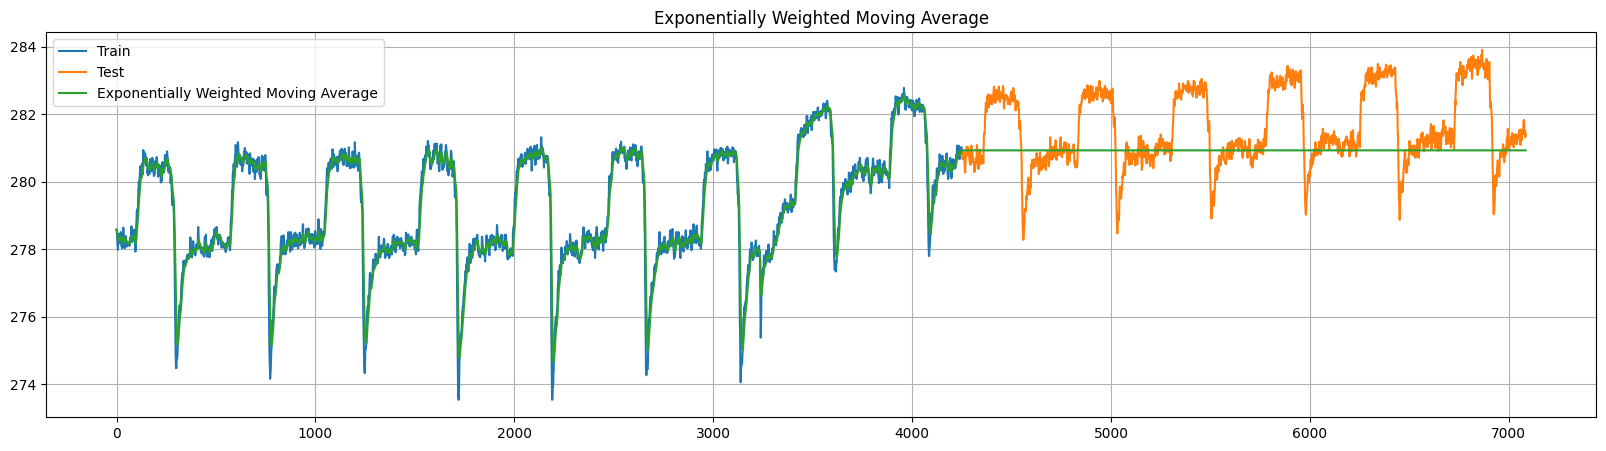

,Method,RMSE,MAPE
0,Exponentially Weighted Moving Average,1.28,0.34


In [7]:
y_hat_ewma = df.copy()
ewm_span = 12
y_hat_ewma['ewma_forecast'] = df['DO'].ewm(span=ewm_span, adjust=False).mean()
y_hat_ewma['ewma_forecast'][train_len:] = y_hat_ewma['ewma_forecast'][train_len-1]

plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['DO'], label='Train')
plt.plot(test['DO'], label='Test')
plt.plot(y_hat_ewma['ewma_forecast'], label='Exponentially Weighted Moving Average')
plt.legend(loc='best')
plt.title('Exponentially Weighted Moving Average')
plt.show()

rmse = np.sqrt(mean_squared_error(test['DO'], y_hat_ewma['ewma_forecast'][train_len:])).round(2)
mape = np.round(np.mean(np.abs(test['DO']-y_hat_ewma['ewma_forecast'][train_len:])/test['DO'])*100,2)

results = pd.DataFrame({'Method':['Exponentially Weighted Moving Average'], 'MAPE': [mape], 'RMSE': [rmse]})
results = results[['Method', 'RMSE', 'MAPE']]
results